In [1]:
# Step 1: Import gymnasium and create LunarLander environment
import gymnasium as gym
import matplotlib.pyplot as plt

# Import DDPG from stable-baselines3  #-------
from stable_baselines3 import DDPG  #-------
from stable_baselines3.common.noise import NormalActionNoise  #-------
import numpy as np  #-------

# Import progress bar callback  #-------
from stable_baselines3.common.callbacks import ProgressBarCallback  #-------

# Import Monitor for logging rewards  #-------
from stable_baselines3.common.monitor import Monitor  #-------

import pandas as pd  #-------
import os  #-------

2025-05-03 21:06:49.153931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-03 21:06:49.168380: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-03 21:06:49.172805: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-03 21:06:49.184145: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Action Space: Box(-1.0, 1.0, (2,), float32)
Observation Space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


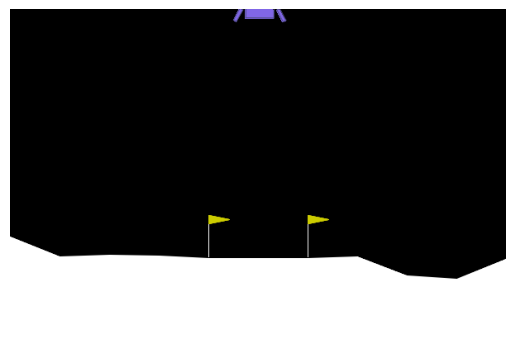

In [2]:
# Create the continuous version of the LunarLander-v3 environment
# Note: 'LunarLanderContinuous-v3' uses a Box action space
log_dir = "./ddpg_logs/"  #-------
os.makedirs(log_dir, exist_ok=True)  #-------
env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
env = Monitor(env, filename=log_dir + "monitor.csv")  #-------


# Step 2: Check if LunarLander is discrete or continuous
print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)

# Reset the environment before rendering
observation, info = env.reset()

# Render the first frame and display in notebook
frame = env.render()
plt.imshow(frame)
plt.axis('off')
plt.show()

In [3]:
# Define the action noise for exploration during training  #-------
n_actions = env.action_space.shape[0]  #-------
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))  #-------

# Initialize the DDPG agent  #-------
model = DDPG("MlpPolicy", env, action_noise=action_noise, verbose=0)  #-------

# Train the agent  #-------
model.learn(total_timesteps=100_00, callback=ProgressBarCallback())  #-------



Output()

In [4]:
# Save the trained model (optional)
model.save("ddpg_lunarlander")  #-------


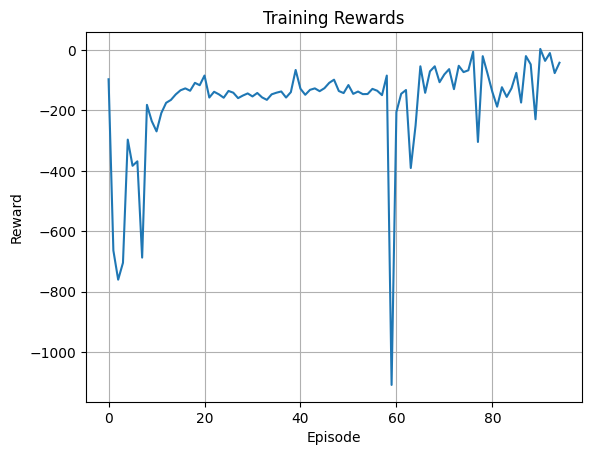

In [5]:
monitor_file = log_dir + "monitor.csv"  #-------
log_data = pd.read_csv(monitor_file, skiprows=1)  #-------
plt.plot(log_data["r"])
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Rewards")
plt.grid(True)
plt.show()  #-------


In [6]:
# Clean up
env.close()